In [6]:

import os
import glob
import sys
notebook_path = os.getcwd()
sys.path.insert(0, os.path.dirname(notebook_path))

from syn_real.measure import hash_links_by_orbit

/home/ka/ka_aifb/ka_cc7738/miniconda3/envs/EAsF/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'/pfs/work9/workspace/scratch/ka_cc7738-orbit-gnn/ANP4Link'

In [7]:
import networkx as nx
import pynauty

def get_graph_orbits(graph: nx.Graph) -> list:
    # Map nodes to consecutive indices
    node_mapping = {node: idx for idx, node in enumerate(graph.nodes())}
    
    # Create adjacency dictionary with remapped indices
    adj_dict = {
        node_mapping[node]: [node_mapping[neighbor] for neighbor in graph.neighbors(node)]
        for node in graph.nodes()
    }
    
    # Construct pynauty graph
    n = len(graph.nodes())
    G_pynauty = pynauty.Graph(number_of_vertices=n, adjacency_dict=adj_dict, directed=False)
    
    # Compute orbits
    _, _, _, orbits, num_orbit = pynauty.autgrp(G_pynauty)
    
    return orbits, num_orbit

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

def plot_degree_distribution(G):
    # Get degree of each node
    degrees = [d for _, d in G.degree()]
    # Count how many nodes have each degree
    degree_counts = Counter(degrees)
    xs = sorted(degree_counts.keys())
    ys = [degree_counts[x] for x in xs]

    # Make the bar‐chart
    plt.figure()
    plt.bar(
        xs,
        ys,
        width=0.8,               # 柱宽，可根据需要调整
        edgecolor='black',       # 边框颜色
        linewidth=0.5,           # 边框线宽
        facecolor='none',        # 填充设为空心
        align='center'           # 居中对齐
    )
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.title("Degree Distribution")
    plt.xticks(xs)
    plt.tight_layout()
    plt.show()

# Example usage:
# import networkx as nx
# G = nx.your_graph_loader_or_constructor(...)
# plot_degree_distribution(G)




Number of orbits: 3, Tree depth: 2


AttributeError: 'list' object has no attribute 'tolist'

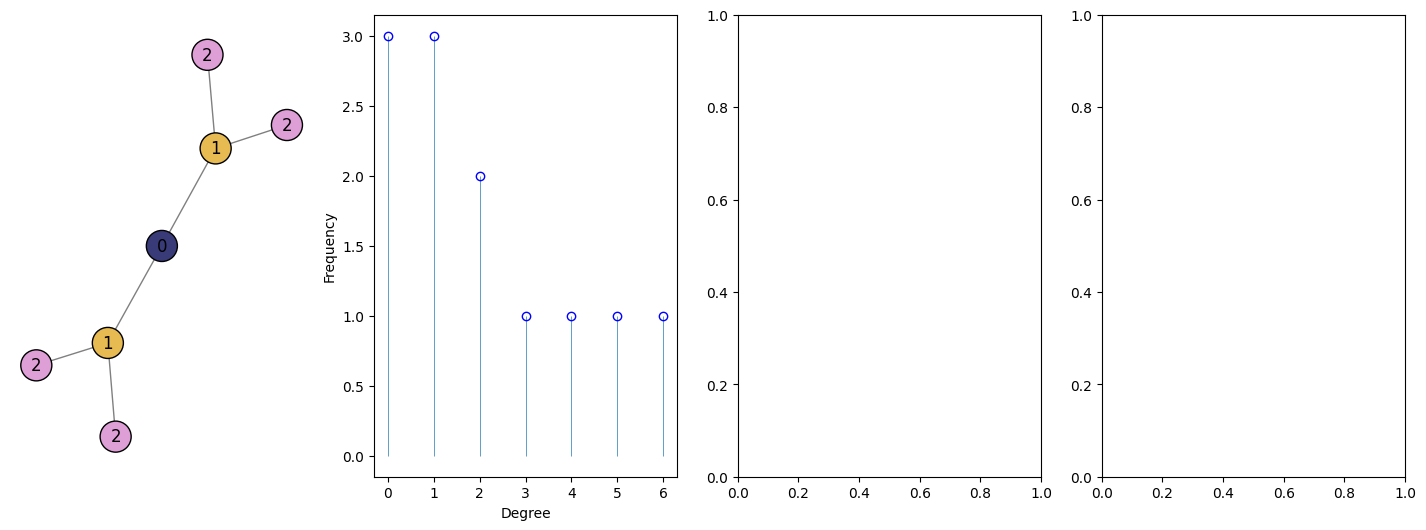

In [ ]:
import networkx as nx
import pynauty
import matplotlib.pyplot as plt
import numpy as np
import itertools



for depth in range(2, 6):  
        branch = 2  
        name = 'balenced_tree'
        tree = nx.balanced_tree(r=branch, h=depth)
        pos = nx.spring_layout(tree, seed=42)

        num_nodes = len(tree.nodes())
        orbits, num_orbit = get_graph_orbits(tree)
        new_label_mapping = {node: idx for idx, node in enumerate(set(orbits))}
        orbits = [new_label_mapping[orbit] for orbit in orbits]

        print(f"Number of orbits: {num_orbit}, Tree depth: {depth}")
        node_colors = [orbits[node] for node in range(num_nodes)]

        custom_labels = {}
        for orbit_idx, orbit in enumerate(orbits):
                custom_labels[orbit_idx] = f"{orbits[orbit_idx]}"  # Label all nodes in the orbit with its index

        fig, axes = plt.subplots(1, 4, figsize=(18, 6))
        nx.draw(
        tree,
        pos,
        with_labels=True,
        labels=custom_labels,
        node_color=node_colors,
        cmap='tab20b',
        node_size=500,
        edge_color="gray",
        edgecolors='black',
        ax=axes[0]
        )

        degrees = [d for _, d in tree.degree()]
        degrees = sorted(degrees, reverse=True)

        markerline, stemlines, _ = axes[1].stem(
                degrees,
                markerfmt='bo',
                basefmt=' '
        )
        markerline.set_markerfacecolor('none')
        stemlines.set_linewidth(0.5)

        axes[1].set_xlabel("Degree")
        axes[1].set_ylabel("Frequency")

        counts = Counter(orbits)
        sizes = sorted(counts.values(), reverse=True)
        markerline, stemlines, _ = axes[2].stem(sizes, markerfmt='bo', basefmt=' ')
        markerline.set_markerfacecolor('none')
        stemlines.set_linewidth(0.5)
        axes[2].set_xlabel("Orbit Index")
        axes[2].set_ylabel("Orbit Size")
        axes[2].set_title("Sorted Orbit Size")
        axes[2].grid(axis='y', linestyle='--', alpha=0.7)
    
        _, edge_class_counts = hash_links_by_orbit(tree, orbits)
        markerline, stemlines, _ = axes[3].stem(edge_class_counts, markerfmt='bo', basefmt=' ')
        markerline.set_markerfacecolor('none')
        stemlines.set_linewidth(0.5)
        axes[3].set_title('Automorphic Edge Distribution')
        axes[3].set_xlabel("Automorphism Edge Classes")
        axes[3].set_ylabel("Frequency")
        
        # plot_edge_distribution(G, orbits, ax=axes[3])
        plt.tight_layout()
        plt.show()

        # plot_degree_distribution(tree)

In [ ]:
def analyze_regular_graph(N:int):
        name = 'grid'
        G_nx = nx.grid_2d_graph(N, N)
        pos_original = {node: (node[1], -node[0]) for node in G_nx.nodes()}  
        node_mapping = {node: idx for idx, node in enumerate(G_nx.nodes())}
        adj_dict = {node_mapping[node]: [node_mapping[neighbor] for neighbor in G_nx.neighbors(node)] 
                for node in G_nx.nodes()}
        n = len(G_nx.nodes())
        G_pynauty = pynauty.Graph(number_of_vertices=n, adjacency_dict=adj_dict, directed=False)
        
        generators, _, _,  orbits, num_orbit  = pynauty.autgrp(G_pynauty)
        new_label_mapping = {node: idx for idx, node in enumerate(set(orbits))}
        orbits = [new_label_mapping[orbit] for orbit in orbits]
        custom_labels = {}
        for i, ov in zip(G_nx.nodes(), orbits):
                custom_labels[i] = f"{ov}"
                
        fig, axes = plt.subplots(1, 4, figsize=(18, 6))
        node_colors = [orbits[node] for node in range(n)]  
        nx.draw(G_nx,  
                pos=pos_original, 
                # with_labels=True, 
                labels=custom_labels, 
                node_color=node_colors, 
                cmap='tab20b',
                node_size=500, 
                font_weight='bold',
                edgecolors='black', 
                ax=axes[0])
        axes[0].set_title("Graph Colored by Orbit Labels")

        degrees = [d for _, d in G_nx.degree()]
        degrees = sorted(degrees, reverse=True)

        markerline, stemlines, _ = axes[1].stem(
                degrees,
                markerfmt='bo',
                basefmt=' '
        )
        markerline.set_markerfacecolor('none')
        stemlines.set_linewidth(0.5)

        axes[1].set_xlabel("Degree")
        axes[1].set_ylabel("Frequency")
        
        axes[2].hist(orbits,
                bins=range(min(orbits), max(orbits) + 2),
                align='left',
                rwidth=0.8)
        axes[2].set_xlabel('Orbit Label')
        axes[2].set_ylabel('Frequency')
        axes[2].set_title('Histogram of Orbit Labels')
        axes[2].grid(axis='y', linestyle='--', alpha=0.7)

        
        _, edge_class_counts = hash_links_by_orbit(G_nx, orbits)
        markerline, stemlines, _ = axes[3].stem(edge_class_counts, markerfmt='bo', basefmt=' ')
        markerline.set_markerfacecolor('none')
        stemlines.set_linewidth(0.5)
        axes[3].set_title('Automorphic Edge Distribution')
        axes[3].set_xlabel("Automorphism Edge Classes")
        axes[3].set_ylabel("Frequency")
        
        plt.show()
        plt.close()

        return 

In [ ]:
for N in range(2, 40):
    analyze_regular_graph(N)

In [ ]:
import math
def analyze_tri_graph(N:int):
        m = 1
        for i in range(1, int(math.sqrt(N)) + 1):
            if N % i == 0:
                m = i
        G_nx = nx.triangular_lattice_graph(m, N // m)
        pos_original = {node: (node[1], -node[0]) for node in G_nx.nodes()}  
        node_mapping = {node: idx for idx, node in enumerate(G_nx.nodes())}
        adj_dict = {node_mapping[node]: [node_mapping[neighbor] for neighbor in G_nx.neighbors(node)] 
                for node in G_nx.nodes()}
        n = len(G_nx.nodes())
        G_pynauty = pynauty.Graph(number_of_vertices=n, adjacency_dict=adj_dict, directed=False)
        
        generators, _, _,  orbits, num_orbit  = pynauty.autgrp(G_pynauty)
        new_label_mapping = {node: idx for idx, node in enumerate(set(orbits))}
        orbits = [new_label_mapping[orbit] for orbit in orbits]
        custom_labels = {}
        for i, ov in zip(G_nx.nodes(), orbits):
                custom_labels[i] = f"{ov}"
                
        fig, axes = plt.subplots(1, 4, figsize=(18, 6))
        node_colors = [orbits[node] for node in range(n)]  
        nx.draw(G_nx,  
                pos=pos_original, 
                # with_labels=True, 
                labels=custom_labels, 
                node_color=node_colors, 
                cmap='tab20b',
                node_size=500, 
                font_weight='bold',
                edgecolors='black', 
                ax=axes[0])
        axes[0].set_title("Graph Colored by Orbit Labels")

        degrees = [d for _, d in G_nx.degree()]
        degrees = sorted(degrees, reverse=True)

        markerline, stemlines, _ = axes[1].stem(
                degrees,
                markerfmt='bo',
                basefmt=' '
        )
        markerline.set_markerfacecolor('none')
        stemlines.set_linewidth(0.5)

        axes[1].set_xlabel("Degree")
        axes[1].set_ylabel("Frequency")
        
        axes[2].hist(orbits,
                bins=range(min(orbits), max(orbits) + 2),
                align='left',
                rwidth=0.8)
        axes[2].set_xlabel('Orbit Label')
        axes[2].set_ylabel('Frequency')
        axes[2].set_title('Histogram of Orbit Labels')
        axes[2].grid(axis='y', linestyle='--', alpha=0.7)

        
        _, edge_class_counts = hash_links_by_orbit(G_nx, orbits)
        markerline, stemlines, _ = axes[3].stem(edge_class_counts, markerfmt='bo', basefmt=' ')
        markerline.set_markerfacecolor('none')
        stemlines.set_linewidth(0.5)
        axes[3].set_title('Automorphic Edge Distribution')
        axes[3].set_xlabel("Automorphism Edge Classes")
        axes[3].set_ylabel("Frequency")
        
        plt.show()
        plt.close()

        return 

In [ ]:
for N in range(4, 80, 10):
    analyze_tri_graph(N)

In [ ]:
import math
def analyze_tri_lattice_graph(N:int):
        m = 1
        for i in range(1, int(math.sqrt(N)) + 1):
            if N % i == 0:
                m = i
        G_nx = nx.triangular_lattice_graph(m, N // m)
        pos_original = {node: (node[1], -node[0]) for node in G_nx.nodes()}  
        node_mapping = {node: idx for idx, node in enumerate(G_nx.nodes())}
        adj_dict = {node_mapping[node]: [node_mapping[neighbor] for neighbor in G_nx.neighbors(node)] 
                for node in G_nx.nodes()}
        n = len(G_nx.nodes())
        G_pynauty = pynauty.Graph(number_of_vertices=n, adjacency_dict=adj_dict, directed=False)
        
        generators, _, _,  orbits, num_orbit  = pynauty.autgrp(G_pynauty)
        new_label_mapping = {node: idx for idx, node in enumerate(set(orbits))}
        orbits = [new_label_mapping[orbit] for orbit in orbits]
        custom_labels = {}
        for i, ov in zip(G_nx.nodes(), orbits):
                custom_labels[i] = f"{ov}"
                
        fig, axes = plt.subplots(1, 4, figsize=(18, 6))
        node_colors = [orbits[node] for node in range(n)]  
        nx.draw(G_nx,  
                pos=pos_original, 
                # with_labels=True, 
                labels=custom_labels, 
                node_color=node_colors, 
                cmap='tab20b',
                node_size=500, 
                font_weight='bold',
                edgecolors='black', 
                ax=axes[0])
        axes[0].set_title("Graph Colored by Orbit Labels")

        degrees = [d for _, d in G_nx.degree()]
        degrees = sorted(degrees, reverse=True)

        markerline, stemlines, _ = axes[1].stem(
                degrees,
                markerfmt='bo',
                basefmt=' '
        )
        markerline.set_markerfacecolor('none')
        stemlines.set_linewidth(0.5)

        axes[1].set_xlabel("Degree")
        axes[1].set_ylabel("Frequency")
        
        axes[2].hist(orbits,
                bins=range(min(orbits), max(orbits) + 2),
                align='left',
                rwidth=0.8)
        axes[2].set_xlabel('Orbit Label')
        axes[2].set_ylabel('Frequency')
        axes[2].set_title('Histogram of Orbit Labels')
        axes[2].grid(axis='y', linestyle='--', alpha=0.7)

        
        _, edge_class_counts = hash_links_by_orbit(G_nx, orbits)
        markerline, stemlines, _ = axes[3].stem(edge_class_counts, markerfmt='bo', basefmt=' ')
        markerline.set_markerfacecolor('none')
        stemlines.set_linewidth(0.5)
        axes[3].set_title('Automorphic Edge Distribution')
        axes[3].set_xlabel("Automorphism Edge Classes")
        axes[3].set_ylabel("Frequency")
        
        plt.show()
        plt.close()

        return 

In [ ]:
for N in range(10, 80, 10):
    analyze_tri_lattice_graph(N)